In [1]:
#%pip install python-Levenshtein
#%pip install matplotlib

import Levenshtein
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


In [2]:
from pathlib import Path
import os

# Run once
os.chdir(Path.cwd().parent)
os.chdir(Path.cwd().parent)

print(f"Current working directory: {Path.cwd()}")


Current working directory: /home/daniel/Documents/deepLearning/Project2_TrOCR/Project2Directory


## Evaluation class to ensure valid metrics across team members

In [3]:
class evaluation:
    ### functions for eval metrics, input = (gt, model output list) (ensure order)
    def __init__(self, groundTruth, results):
        self.gt = groundTruth
        self.pred = results

    def accuracy(self):
        correct = (self.gt == self.pred)
        return correct.mean() 

    def character_accuracy(self):
        total_chars = 0
        total_errors = 0

        for gt, pred in zip(self.gt, self.pred):
            gt = str(gt)
            pred = str(pred)

            dist = Levenshtein.distance(gt, pred)

            total_errors += dist
            total_chars += len(gt)

        return 1 - (total_errors / total_chars)

## build dataframe with ground truth and ocr output columns

In [4]:
# Load the ground truth and OCR results (after re-splits)
gt = pd.read_csv("data/OCRcropsv3/test/tradOutputTest/annotatedTestV3.csv")
results = pd.read_csv("data/OCRcropsv3/test/tradOutputTest/baselineOcrResultsTest.csv")

print(f"Total Images in OCR results: {len(results)}")
print(f"Total Null results in OCR results: {len(results[results['best_text'].isnull()])}")

# Extract just the filename, and manunally annotated column
gt["image_name"] = gt["image"].str.split("/").str[-1]
gt = gt.loc[:, ["image_name", "annotated_transcription"]]

results["image_name"] = results["filename"]

val = pd.merge(gt, results, on="image_name", how="inner")
val["best_text"] = val["best_text"].fillna("")
val["annotated_transcription"] = val["annotated_transcription"].replace([0, "0"], "")

print(f"Total Images: {len(val)}")


Total Images in OCR results: 107
Total Null results in OCR results: 5
Total Images: 107


# Evaluate baseline performance

In [5]:
baseline = evaluation(val["annotated_transcription"], val["best_text"])

print(f"Word Accuracy: {baseline.accuracy()}")
print(f"Character Accuracy: {baseline.character_accuracy()}")


Word Accuracy: 0.9252336448598131
Character Accuracy: 0.9278688524590164


In [6]:
errors = val["image_name"][val["annotated_transcription"] != val["best_text"]]
numbers = val["annotated_transcription"][val["annotated_transcription"] != val["best_text"]]
error_numbers = val["best_text"][val["annotated_transcription"] != val["best_text"]]

In [7]:
print(error_numbers)
print(errors)

7       1081
15          
29          
35      3363
44          
45          
100         
103    75060
Name: best_text, dtype: str
7       IMG_0799_jpeg_jpeg2.jpg
15     IMG_0818_jpeg_jpeg20.jpg
29          IMG_0848_jpeg29.jpg
35     IMG_0790_jpeg_jpeg19.jpg
44          IMG_0860_jpeg10.jpg
45          IMG_0855_jpeg26.jpg
100    IMG_0829_jpeg_jpeg14.jpg
103         IMG_0858_jpeg17.jpg
Name: image_name, dtype: object


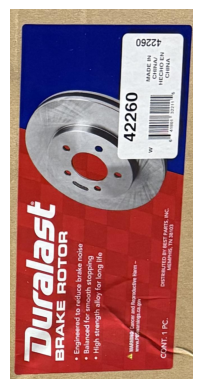

Ground Truth: 42260
Predicted: 1081


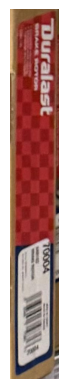

Ground Truth: 70004
Predicted: 


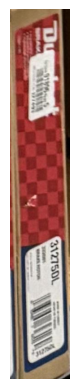

Ground Truth: 31275DL
Predicted: 


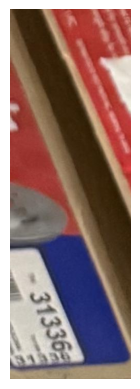

Ground Truth: 31336
Predicted: 3363


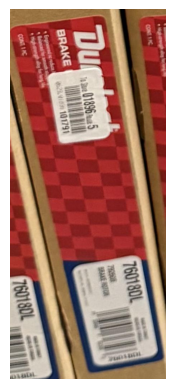

Ground Truth: 76018DL
Predicted: 


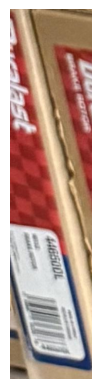

Ground Truth: 44650DL
Predicted: 


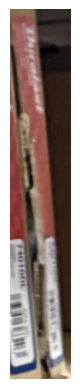

Ground Truth: 74010DL
Predicted: 


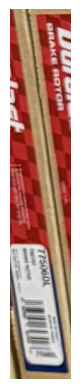

Ground Truth: 77506DL
Predicted: 75060


In [8]:

for error, number, error_number in zip(errors, numbers, error_numbers):
    img = mpimg.imread("data/OCRcropsv3/test/rawCropTest/" + error)  
    plt.imshow(img)
    plt.axis('off')  
    plt.show()
    print(f"Ground Truth: {number}")
    print(f"Predicted: {error_number}")